In [8]:
import pandas as pd
import numpy as np

In [20]:
df = pd.read_csv("cleaned_student_performane.csv")

In [21]:
df.head()


,gender,race-ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score,result,grade_category
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,Pass,good
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,Pass,Very Good
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,Pass,Excellent
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,Pass,Average
4,male,group C,some college,standard,none,76,78,75,229,76.333333,Pass,Very Good


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race-ethnicity               1000 non-null   object 
 2   parental_level_of_education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test_preparation_course      1000 non-null   object 
 5   math_score                   1000 non-null   int64  
 6   reading_score                1000 non-null   int64  
 7   writing_score                1000 non-null   int64  
 8   total_score                  1000 non-null   int64  
 9   average_score                1000 non-null   float64
 10  result                       1000 non-null   object 
 11  grade_category               1000 non-null   object 
dtypes: float64(1), int64(4), object(7)
memory usage: 93.9+ KB


In [23]:
df.columns

Index(['gender', 'race-ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total_score', 'average_score', 'result',
       'grade_category'],
      dtype='object')

In [24]:
df["result"].value_counts()

result
Pass    971
Fail     29
Name: count, dtype: int64

In [25]:
features = [
    "gender",
    "parental_level_of_education",
    "lunch",
    "test_preparation_course",
    "math_score",
    "reading_score",
    "writing_score"
]

X = df[features]

y = df["result"]

In [26]:
X.head()

,gender,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,bachelor's degree,standard,none,72,72,74
1,female,some college,standard,completed,69,90,88
2,female,master's degree,standard,none,90,95,93
3,male,associate's degree,free/reduced,none,47,57,44
4,male,some college,standard,none,76,78,75


In [27]:
y.head()

0    Pass
1    Pass
2    Pass
3    Pass
4    Pass
Name: result, dtype: object

In [28]:
from sklearn.preprocessing import LabelEncoder

In [29]:
le = LabelEncoder()

In [31]:
X = X.copy()
for col in X.select_dtypes(include="object").columns:
    X.loc[:, col] = le.fit_transform(X[col])

In [32]:
y = le.fit_transform(y)

In [33]:
X.head()

,gender,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,0,1,1,1,72,72,74
1,0,4,1,0,69,90,88
2,0,3,1,1,90,95,93
3,1,0,0,1,47,57,44
4,1,4,1,1,76,78,75


In [34]:
y[:5]

array([1, 1, 1, 1, 1])

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
print(X_train.shape)
print(X_test.shape)

(800, 7)
(200, 7)


In [38]:
from sklearn.ensemble import RandomForestClassifier

In [39]:
model = RandomForestClassifier()

In [40]:
model.fit(X_train, y_train)

RandomForestClassifier()

In [41]:
y_pred = model.predict(X_test)

In [42]:
y_pred[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [44]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.985


In [45]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.99      0.99      0.99       190

    accuracy                           0.98       200
   macro avg       0.94      0.90      0.92       200
weighted avg       0.98      0.98      0.98       200



In [47]:
print(confusion_matrix(y_test, y_pred))

[[  8   2]
 [  1 189]]


In [48]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                       Feature  Importance
4                   math_score    0.343215
5                reading_score    0.303092
6                writing_score    0.296118
2                        lunch    0.020140
0                       gender    0.016578
1  parental_level_of_education    0.014002
3      test_preparation_course    0.006856


In [49]:
import matplotlib.pyplot as plt

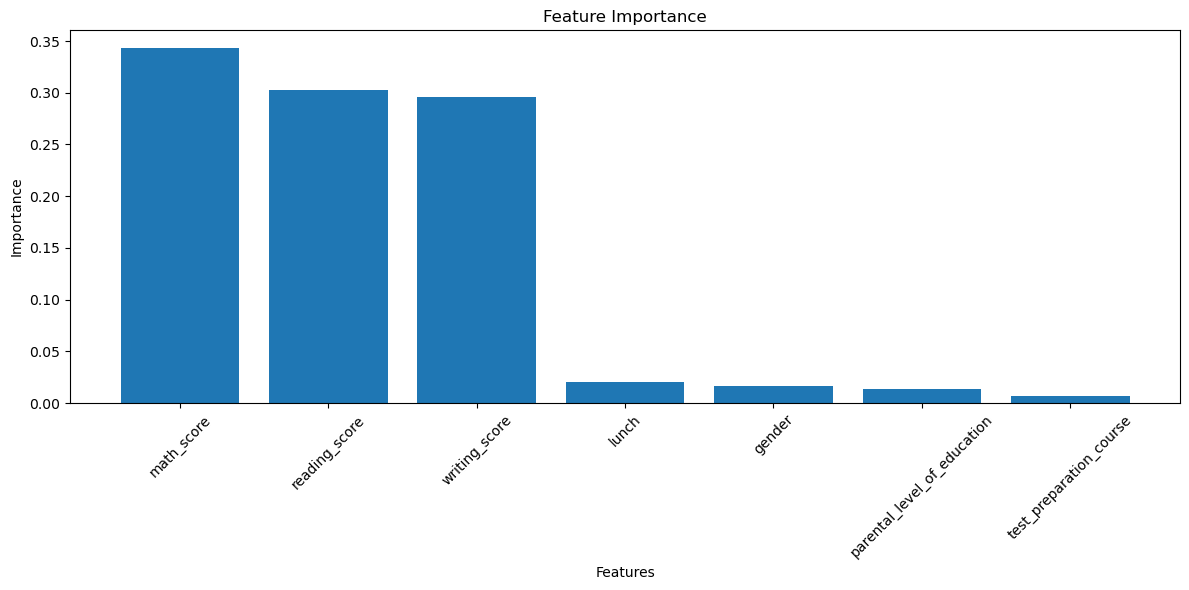

In [51]:
plt.figure(figsize=(12,6))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Key ML Insights
- Academic scores were the strongest predictors of pass/fail outcomes.
- Reading and writing scores showed high influence on predictions.
- Demographic features had lower impact compared to academic performance.
- The Random Forest model achieved high prediction accuracy.